<a href="https://colab.research.google.com/github/rianto42/NLPAssignment3/blob/main/NLP_Assignment3_Wed_Morning_18.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
!pip install kagglehub
!pip install langdetect
!pip install transformers
!pip install datasets

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 981.5/981.5 kB 20.0 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Created wheel for langdetect: filename=langdetect-1.0.9-py3-none-any.whl size=993223 sha256=37a959b9f180a034aa99bae3d7aa2e3f447b1258f9e3476bf0840733c74fed31
  Stored in directory: /root/.cache/pip/wheels/0a/f2/b2/e5ca405801e05eb7c8ed5b3b4bcf1fcabcd6272c167640072e
Successfully built langdetect
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 491.5/491.5 kB 11.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 116.3/116.3 kB 11.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 193.6/193.6 kB 17.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 143.5/143.5 kB 13.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 194.8/194.8 kB 16.8 MB/s eta 0:00:00
  Attempting uninstall: fsspec
    Found existing installation: fsspec 2025.3.2
    Uninstalling fsspec-2025.3.2:
      Successfully uninstalled fsspec-2025.3.2
ERROR: pip's dep

### Import Library

In [3]:
# Disable W&B logging for clean ouput
import os
os.environ["WANDB_DISABLED"] = "true"
import kagglehub
import numpy as np
import pandas as pd
from langdetect import detect
from sklearn.model_selection import train_test_split
from transformers import DistilBertConfig, DistilBertTokenizerFast, DistilBertForSequenceClassification, Trainer, TrainingArguments
# from torch.utils.data import Dataset
from datasets import DatasetDict, Dataset
from sklearn.metrics import accuracy_score
import torch.nn as nn
import torch
from sklearn.utils.class_weight import compute_class_weight

### Download dataset from kaggle

In [4]:
# Download dataset
def load_dataset(used_column):
    dataset_path = kagglehub.dataset_download("tobiasbueck/multilingual-customer-support-tickets")
    print("dataset downloaded to this path:", dataset_path)
    ds = pd.read_csv(os.path.join(dataset_path,'aa_dataset-tickets-multi-lang-5-2-50-version.csv'),usecols=used_column)
    ds = ds.rename(columns={'queue': 'label'})
    return ds

### Cleansing and Preprocessing dataset

In [5]:
# Retain necessary columns
used_column = ['body','queue'] #['type','queue','priority']
ds = load_dataset(used_column)

# Check null label value, and discard the value
if ds['label'].isnull().any():
    print('There are some rows that has null label value, discard the rows')
    ds = ds.dropna(subset=['label'])

# We use the langdetect library to label the language used in the text
ds['lang'] = ds['body'].apply(lambda x: detect(str(x)))

dataset downloaded to this path: /kaggle/input/multilingual-customer-support-tickets


In [6]:
# Discard non english text
ds = ds[ds['lang'] == 'en']
ds = ds.drop(columns=['lang']).reset_index(drop=True)

# Display labels
print('Unique value for category:', ds['label'].unique())
# Check label distribution
print('Label freq:', ds['label'].value_counts(normalize=True) * 100)
# Display total row number for each label
print('Label freq:', ds['label'].value_counts())

# Enumerate categories
label2id = {label: idx for idx, label in enumerate(ds['label'].unique())}
ds['label'] = ds['label'].map(label2id)

# reverse
# id2label = {v: k for k, v in label2id.items()}

Unique value for category: ['Technical Support' 'Returns and Exchanges' 'Billing and Payments'
 'Sales and Pre-Sales' 'Service Outages and Maintenance' 'Product Support'
 'IT Support' 'Customer Service' 'Human Resources' 'General Inquiry']
Label freq: label
Technical Support                  29.416267
Product Support                    18.512093
Customer Service                   14.618839
IT Support                         12.052250
Billing and Payments                9.761200
Returns and Exchanges               5.102561
Service Outages and Maintenance     4.056536
Sales and Pre-Sales                 3.041127
Human Resources                     2.051230
General Inquiry                     1.387897
Name: proportion, dtype: float64
Label freq: label
Technical Support                  5765
Product Support                    3628
Customer Service                   2865
IT Support                         2362
Billing and Payments               1913
Returns and Exchanges              1000
S

In [7]:
ds_ready = ds.copy()

In [10]:
# Split the dataset
train_ds, test_ds = train_test_split(ds_ready, test_size=0.2, random_state=42, stratify=ds_ready['label'])

In [11]:
# Convert to Huggingface dataset object
train_dataset = Dataset.from_pandas(train_ds.reset_index(drop=True))
test_dataset = Dataset.from_pandas(test_ds.reset_index(drop=True))
ready_dataset = DatasetDict({
    "train": train_dataset,
    "test": test_dataset
})

### Tokenize

In [12]:
model_name = 'distilbert-base-uncased'
tokenizer = DistilBertTokenizerFast.from_pretrained(model_name)

def tokenize_function(datas):
    return tokenizer(datas["body"], padding="max_length", truncation=True, max_length=114)

tokenized_dataset = ready_dataset.map(tokenize_function, batched=True)
tokenized_dataset.set_format(type="torch", columns=["input_ids", "attention_mask", "label"])

/usr/local/lib/python3.11/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

config.json:   0%|          | 0.00/483 [00:00<?, ?B/s]

Map:   0%|          | 0/15678 [00:00<?, ? examples/s]

Map:   0%|          | 0/3920 [00:00<?, ? examples/s]

Token Length Stats:
  - Max token length     : 246
  - 95th percentile      : 114
  - Mean token length    : 67

 Recommended max_length: 114 (covers 95% of your data)


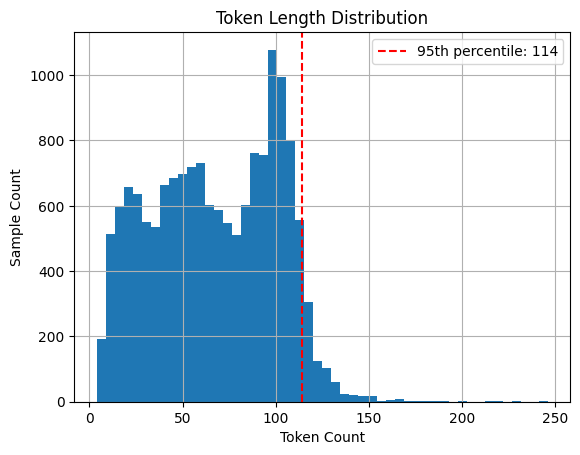

In [25]:
from transformers import DistilBertTokenizerFast
import numpy as np
import matplotlib.pyplot as plt

# Load tokenizer
tokenizer = DistilBertTokenizerFast.from_pretrained("distilbert-base-uncased")

# Analyze token lengths (without truncation)
token_lengths = [len(tokenizer.encode(text, truncation=False)) for text in train_ds['body']]

# Statistics
max_len = np.max(token_lengths)
p95 = int(np.percentile(token_lengths, 95))
mean_len = int(np.mean(token_lengths))

print(f"Token Length Stats:")
print(f"  - Max token length     : {max_len}")
print(f"  - 95th percentile      : {p95}")
print(f"  - Mean token length    : {mean_len}")
print(f"\n Recommended max_length: {p95} (covers 95% of your data)")

# Optional: plot distribution
plt.hist(token_lengths, bins=50)
plt.axvline(p95, color='r', linestyle='--', label=f'95th percentile: {p95}')
plt.title("Token Length Distribution")
plt.xlabel("Token Count")
plt.ylabel("Sample Count")
plt.legend()
plt.grid(True)
plt.show()


### Load Model

In [13]:
num_labels = ds_ready['label'].nunique()
# model = DistilBertForSequenceClassification.from_pretrained(model_name, num_labels=num_labels)

# Get class weights based on label column
class_weights = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(ds_ready['label']),
    y=ds_ready['label']
)

# Convert to tensor for PyTorch
class_weights_tensor = torch.tensor(class_weights, dtype=torch.float)

class WeightedDistilBERT(DistilBertForSequenceClassification):
    def __init__(self, config, class_weights):
        super().__init__(config)
        self.class_weights = class_weights

    def compute_loss(self, model, inputs, return_outputs=False):
        labels = inputs.get("labels")
        outputs = model(**inputs)
        logits = outputs.get("logits")
        loss_fct = nn.CrossEntropyLoss(weight=self.class_weights.to(logits.device))
        loss = loss_fct(logits, labels)
        return (loss, outputs) if return_outputs else loss

# Config with correct number of labels
config = DistilBertConfig.from_pretrained("distilbert-base-uncased", num_labels=num_labels)

# Initialize model with custom weights
model = WeightedDistilBERT(config, class_weights_tensor)

### Train Model

In [80]:
# Define a metric function to compute accuracy during evaluation
def compute_metrics(eval_pred):
    logits, labels = eval_pred  # Extract model outputs (logits) and true labels
    predictions = np.argmax(logits, axis=-1)  # Choose the class with the highest score
    acc = accuracy_score(labels, predictions)  # Compute accuracy using sklearn
    return {"accuracy": acc}  # Return as a dictionary for Hugging Face's Trainer

In [14]:
from sklearn.metrics import accuracy_score, precision_recall_fscore_support

def compute_metrics(eval_pred):
    logits, labels = eval_pred
    predictions = logits.argmax(axis=-1)

    precision, recall, f1, _ = precision_recall_fscore_support(labels, predictions, average='weighted')
    acc = accuracy_score(labels, predictions)

    return {
        'accuracy': acc,
        'precision': precision,
        'recall': recall,
        'f1': f1
    }

In [15]:
training_args = TrainingArguments(
    output_dir="./results",
    eval_strategy="epoch",
    save_strategy="epoch",
    per_device_train_batch_size=16,
    per_device_eval_batch_size=16,
    num_train_epochs=5,
    weight_decay=0.01,
    logging_dir="./logs",
    logging_steps=10
)

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=tokenized_dataset["train"],
    eval_dataset=tokenized_dataset["test"],
    compute_metrics=compute_metrics
)

trainer.train()

Using the `WANDB_DISABLED` environment variable is deprecated and will be removed in v5. Use the --report_to flag to control the integrations used for logging result (for instance --report_to none).


Epoch,Training Loss,Validation Loss


KeyboardInterrupt: 

In [63]:
# Run evaluation on the test set using the trained model
post_results = trainer.evaluate()  # Returns a dictionary with evaluation metrics

# Extract the post-training accuracy
post_acc = post_results["eval_accuracy"]
print("📈 Accuracy after fine-tuning:", post_acc)

📈 Accuracy after fine-tuning: 0.6284111196123437
